In [5]:
import numpy               as np
#import seaborn             as sns
import pandas              as pd
import libraries.plotting  as slp
import libraries.utilities as sul
import os

#sns.set_theme()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name to reference folder which stores the energies of each slab
material = 'SbSeBr'
slab_folder = f'/Users/cibran/Desktop/MChX-slabs/parent-compounds/{material}-slab/slabs'
#slab_folder = f'/Users/cibran/Desktop/band-alignments/Bi2S3/slab_v0'

The surface formation energy ($E_{surface}$) can be expressed in terms of the area ($S$) of the surface, the energy ($E_{slab}$) of the slab and the energy of the bulk system ($E_{bulk}$) as:

\begin{equation}
    E_{surface} = \frac{E_{slab} - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [3]:
bulk_folder = f'{slab_folder}/bulk'

# Load the bulk energy
bulk_energy = sul.read_energy(bulk_folder)

# Load bulk information
slab_data = sul.load_json(filename=f'{bulk_folder}/slab_data.json')

n_bulk = slab_data['number_of_sites']

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:2750: UnknownPotcarWarning: POTCAR data with symbol Sb is not known to pymatgen. Your POTCAR may be corrupted or pymatgen's POTCAR database is incomplete.
  psingle = PotcarSingle(f"{p_strip}\nEnd of Dataset\n")


In [4]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
surface_energies_of_formation = {}
for i, miller_index_str in enumerate(os.listdir(slab_folder)):
    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'
    print(miller_folder)
    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(miller_folder)) or (miller_index_str == 'bulk'):
        continue

    # Load slab information
    slab_data = sul.load_json(filename=f'{miller_folder}/slab_data.json')

    print()
    print(f'Slab {i+1}')
    print()
    print(f'Miller index: {slab_data['miller_index']}')
    print(f'Shift: {slab_data['shift']:.3g}')
    print(f'Surface area: {slab_data['surface_area']:.3g}')
    print(f'Number of sites: {slab_data['number_of_sites']}')

    # Load the single-shot energy
    slab_energy = sul.read_energy(miller_folder)

    print(f'E_total = {slab_energy:.3g} eV')

    bulk_energy_times_fu = bulk_energy * slab_data['number_of_sites'] / n_bulk
    
    # Compute surface energy of formation in eV/atom/ang^2
    surface_energy_of_formation = sul.get_surface_energy_of_formation(slab_energy, bulk_energy_times_fu, slab_data['surface_area'])

    # Save the slab energy
    np.savetxt(f'{miller_folder}/surface_energy_of_formation', [surface_energy_of_formation])

    print(f'\t$E_surface$ = {surface_energy_of_formation:.3g} J/m²')

    # Generate a dictionary object with the new data and update in the main data object
    surface_energies_of_formation.update({
        miller_index_str: surface_energy_of_formation
    })

# Convert to Pandas DataFrame
surface_energies_of_formation = pd.DataFrame(surface_energies_of_formation, index=['energy'])

/Users/cibran/Desktop/MChX-slabs/parent-compounds/SbSeBr-slab/slabs/2_1_0_e

Slab 1

Miller index: [2, 1, 0]
Shift: 0.0767
Surface area: 169
Number of sites: 144
E_total = -548 eV
	$E_surface$ = 0.349 J/m²
/Users/cibran/Desktop/MChX-slabs/parent-compounds/SbSeBr-slab/slabs/2_1_0_b

Slab 2

Miller index: [2, 1, 0]
Shift: 0.125
Surface area: 169
Number of sites: 144
E_total = -548 eV
	$E_surface$ = 0.317 J/m²
/Users/cibran/Desktop/MChX-slabs/parent-compounds/SbSeBr-slab/slabs/1_1_1_a

Slab 3

Miller index: [1, 1, 1]
Shift: 0.45
Surface area: 96.9
Number of sites: 72
E_total = -273 eV
	$E_surface$ = 0.37 J/m²
/Users/cibran/Desktop/MChX-slabs/parent-compounds/SbSeBr-slab/slabs/2_1_2_a

Slab 4

Miller index: [2, 1, 2]
Shift: 0.191
Surface area: 181
Number of sites: 144
E_total = -547 eV
	$E_surface$ = 0.354 J/m²
/Users/cibran/Desktop/MChX-slabs/parent-compounds/SbSeBr-slab/slabs/1_1_1_t

Slab 5

Miller index: [1, 1, 1]
Shift: 0.327
Surface area: 96.9
Number of sites: 72
E_total = -273 eV
	$

# Extract local minimas and generate input files

In [5]:
min_arg      = np.argsort(surface_energies_of_formation.values)[0]
local_minima = surface_energies_of_formation.columns[min_arg]
energies     = surface_energies_of_formation.values[0][min_arg]
#local_minima, energies

In [6]:
min_arg_sort = surface_energies_of_formation.T.sort_values(by='energy', ascending=True)
min_arg_sort.to_excel(f'{slab_folder}/{material}-sorted_data.xlsx')

In [7]:
import seaborn as sns
sns.set_style("whitegrid")

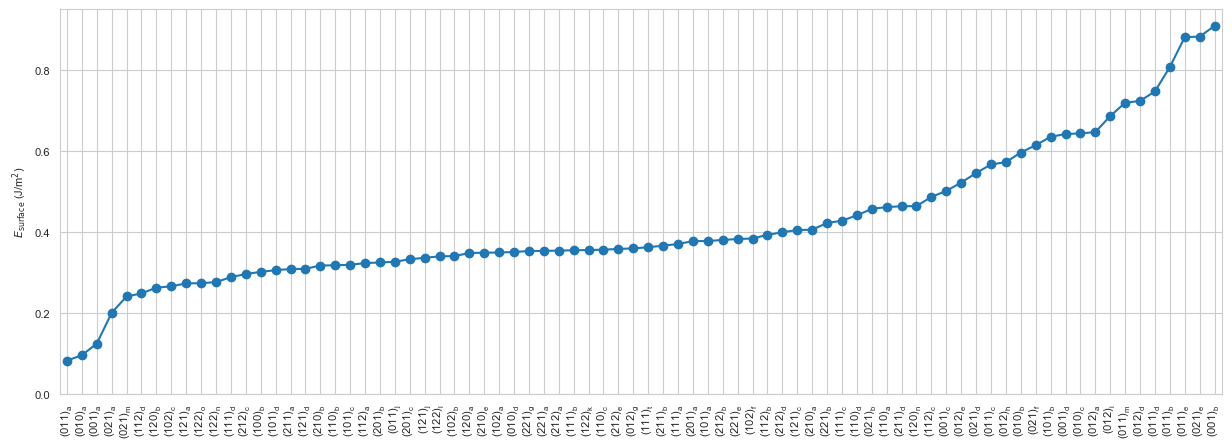

In [8]:
slp.plot_ranking(surface_energies_of_formation,
                 ylabel=r'$E_{\text{surface}}$ (J/m$^2$)',
                 filename=f'{slab_folder}/ranking.png', dpi=300)

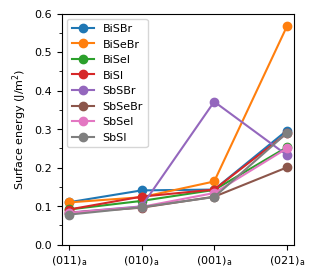

In [9]:
import numpy             as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_materials(
    data,
    filename='materials.png',
    figsize=(3, 3),
    ylabel='Value',
    dpi=300
):

    plt.figure(figsize=figsize)

    for material in data.columns:
        plt.plot(
            range(len(data.index)),
            data[material].values,
            'o-',
            label=material
        )

    # Format Miller indices
    hkl = []
    for label in data.index:
        sp = label.split('_')
        if len(sp) == 5:
            h, k, l, _, i = sp
            if int(i) < 10:
                i = '0' + i
        else:
            h, k, l, i = sp
        hkl.append(f'$\\mathregular{{({h}{k}{l})_{{{i}}}}}$')

    plt.xlim(-0.1, len(data.index) -1 + 0.1)
    plt.tick_params(bottom=True, left=True)
    plt.ylim(0, 0.6)
    plt.xticks(range(len(data.index)), hkl, rotation='horizontal')
    plt.ylabel(ylabel)
    plt.grid(False)
    from matplotlib.ticker import MultipleLocator

    ax = plt.gca()
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    plt.legend(loc='best')

    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.show()

data = pd.DataFrame(
    {
        "BiSBr":  [0.110200348080715, 0.140988332672125, 0.143142645786765, 0.296539789789238],
        "BiSeBr": [0.109749617381569, 0.123310839001083, 0.164204010372505, 0.566765544563390],
        "BiSeI":  [0.0914072264721066, 0.113689200278146, 0.142200645666916, 0.253124814339922],
        "BiSI":   [0.0912827619884776, 0.124799207395550, 0.143163059681579, 0.289140945155283],
        "SbSBr":  [0.0833346576898917, 0.0994673672797144, 0.371439793216549, 0.232748491789582],
        "SbSeBr": [0.0827167974876382, 0.0961211404140130, 0.124559834946533, 0.200627756732281],
        "SbSeI":  [0.0826620423658792, 0.0982380097322544, 0.134145674058586, 0.250001358292077],
        "SbSI":   [0.0780454270916133, 0.0974209577551224, 0.123695459685976, 0.290190735391304],
    },
    index=["0_1_1_a", "0_1_0_a", "0_0_1_a", "0_2_1_a"],
)

plot_materials(
    data,
    ylabel='Surface energy (J/m$^2$)',
    filename='materials.png',
    dpi=300
)